<a href="https://colab.research.google.com/github/debo-ogunnowo/Prompt-Inference-System/blob/main/prompt_embedding_space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/FYP/final_reconstruction_evaluation_results.csv')

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Encoding original and reconstructed prompts
original_embeddings = model.encode(df['message'].tolist(), show_progress_bar=True)
reconstructed_embeddings = model.encode(df['reconstructed_prompt'].tolist(), show_progress_bar=True)

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

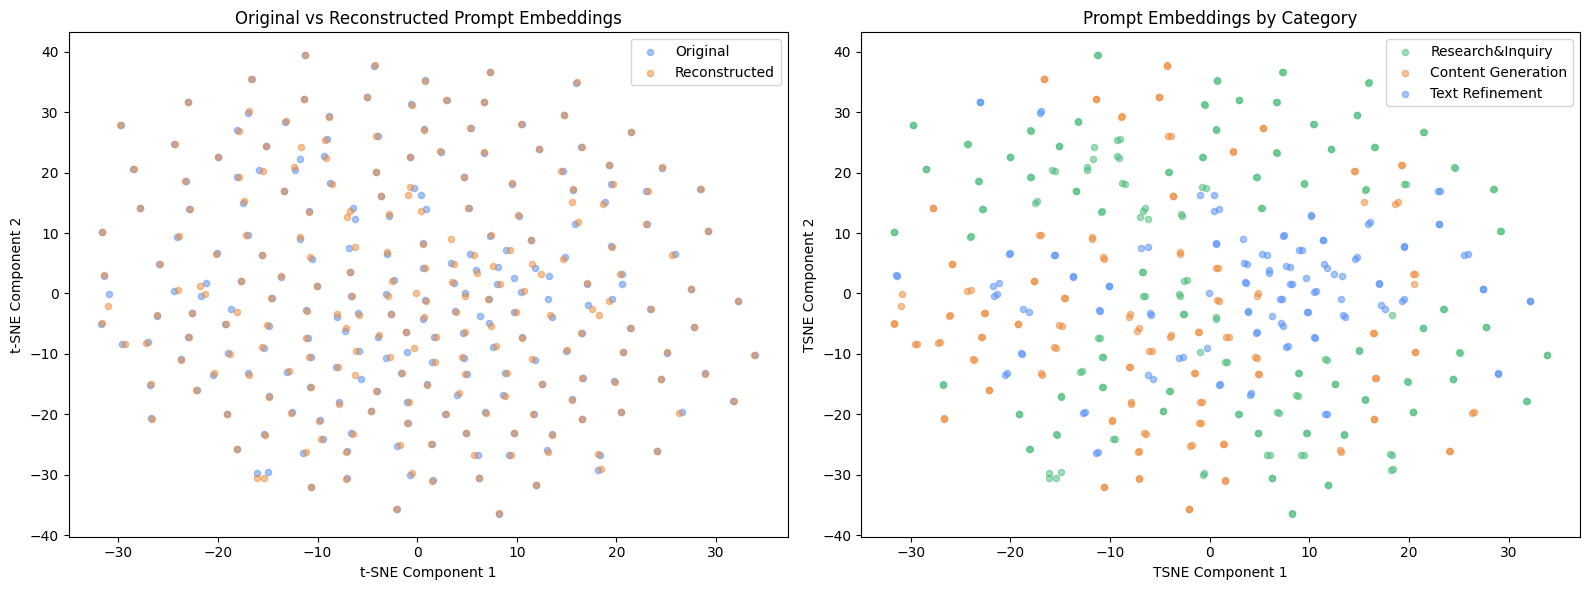

In [ ]:
# Combining all embeddings for joint dimensionality reduction
all_embeddings = np.vstack([original_embeddings, reconstructed_embeddings])
labels = ['Original'] * len(df) + ['Reconstructed'] * len(df)
categories = list(df['original_category']) * 2

# Reducing to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(all_embeddings)

# Plot 1: Original vs Reconstructed clustering
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_type = {'Original': '#4f8ef7', 'Reconstructed': '#ed8936'}
for label, color in colors_type.items():
    mask = [l == label for l in labels]
    axes[0].scatter(
        reduced[mask, 0], reduced[mask, 1],
        c=color, label=label, alpha=0.5, s=20
    )
axes[0].set_title('Original vs Reconstructed Prompt Embeddings')
axes[0].legend()
axes[0].set_xlabel('t-SNE Component 1')
axes[0].set_ylabel('t-SNE Component 2')

# Plot 2: Category clustering
category_colors = {
    'Research&Inquiry': '#48bb78',
    'Content Generation': '#ed8936',
    'Text Refinement': '#4f8ef7'
}
for cat, color in category_colors.items():
    mask = [c == cat for c in categories]
    axes[1].scatter(
        reduced[mask, 0], reduced[mask, 1],
        c=color, label=cat, alpha=0.5, s=20
    )
axes[1].set_title('Prompt Embeddings by Category')
axes[1].legend()
axes[1].set_xlabel('TSNE Component 1')
axes[1].set_ylabel('TSNE Component 2')

plt.tight_layout()
plt.savefig('embedding_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
print("Threshold | Proportion Above | Category Match Rate for Pairs Above Threshold")
print("-" * 70)

for t in thresholds:
    mask = df['cosine similarity'] >= t
    proportion = mask.mean()
    if mask.sum() > 0:
        consistency = df[mask]['category_match'].mean()
    else:
        consistency = 0
    print(f"  {t:.1f}    |      {proportion:.4f}       |           {consistency:.4f}")

Threshold | Proportion Above | Category Match Rate for Pairs Above Threshold
----------------------------------------------------------------------
  0.3    |      0.9869       |           0.7920
  0.4    |      0.9782       |           0.7946
  0.5    |      0.9563       |           0.8128
  0.6    |      0.9301       |           0.8263
  0.7    |      0.8472       |           0.8454
  0.8    |      0.6550       |           0.8733
  0.9    |      0.3930       |           0.9000


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

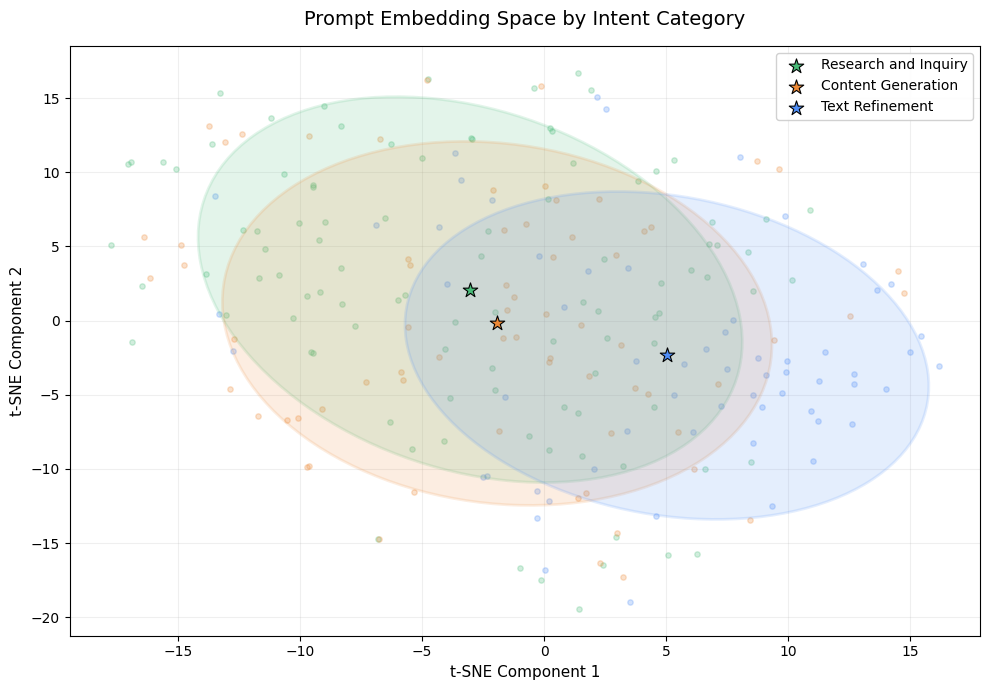

In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

embeddings = model.encode(df['message'].tolist(), show_progress_bar=True)

# Reduce to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(embeddings)
df['x'] = reduced[:, 0]
df['y'] = reduced[:, 1]

def confidence_ellipse(x, y, ax, n_std=1.5, **kwargs):
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx, ry = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx * 2, height=ry * 2, **kwargs)
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_x, mean_y = np.mean(x), np.mean(y)
    transform = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)
    ellipse.set_transform(transform + ax.transData)
    return ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(10, 7))

category_config = {
    'Research&Inquiry':   {'color': '#48bb78', 'label': 'Research and Inquiry'},
    'Content Generation': {'color': '#ed8936', 'label': 'Content Generation'},
    'Text Refinement':    {'color': '#4f8ef7', 'label': 'Text Refinement'},
}

for cat, config in category_config.items():
    mask = df['original_category'] == cat
    x = df[mask]['x'].values
    y = df[mask]['y'].values

    # Plot individual points with low alpha
    ax.scatter(x, y, c=config['color'], alpha=0.25, s=15, zorder=2)

    # Plot centroid
    ax.scatter(np.mean(x), np.mean(y),
               c=config['color'], s=120, marker='*',
               edgecolors='black', linewidths=0.8,
               label=config['label'], zorder=4)

    # Plot confidence ellipse
    confidence_ellipse(x, y, ax,
                      n_std=1.5,
                      alpha=0.15,
                      facecolor=config['color'],
                      edgecolor=config['color'],
                      linewidth=2,
                      zorder=3)

ax.set_title('Prompt Embedding Space by Intent Category', fontsize=14, pad=15)
ax.set_xlabel('t-SNE Component 1', fontsize=11)
ax.set_ylabel('t-SNE Component 2', fontsize=11)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('category_clusters_ellipse.png', dpi=150, bbox_inches='tight')
plt.show()